In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("dataset/resumeJD_pairs.csv", engine="python", on_bad_lines="skip")
print(f"Data loaded successfully: {df.shape[0]:,} rows and {df.shape[1]} columns.")
print(f"\nColumns: {list(df.columns)}")

Data loaded successfully: 6,241 rows and 4 columns.

Columns: ['resume_text', 'job_description_text', 'label', 'match_score']


In [3]:
print("Missing values Analysis:")
print("=" * 60)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100  
missing_df = pd.DataFrame({"Missing Values": missing_values, "Percentage": missing_percent})

print(missing_df)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing values Analysis:
                      Missing Values  Percentage
resume_text                        0         0.0
job_description_text               0         0.0
label                              0         0.0
match_score                        0         0.0

Total missing values: 0


In [4]:
full_dupes = df.duplicated().sum()
print(f"\nTotal duplicate rows: {full_dupes}")


Total duplicate rows: 1


In [5]:
pair_dupes = df.duplicated(subset=["resume_text", "job_description_text"]).sum()
print(f"Duplicate rows based on 'resume_text' and 'job_description_text': {pair_dupes}")

Duplicate rows based on 'resume_text' and 'job_description_text': 7


In [6]:
print("\nDuplicate rows:")
df[df.duplicated(subset=["resume_text", "job_description_text"], keep=False)]


Duplicate rows:


,resume_text,job_description_text,label,match_score
46,SummaryDynamic and motivated IT professional w...,Business Analyst Location: Remote.Duration: 12...,No Fit,0.6018
312,SummaryHighly motivated Sales Associate with e...,Alexander Technology Group is currently exclus...,No Fit,0.6243
377,ProfileOver 4 Years of Business Intelligence /...,Role - Business Analyst - Mobile Location - Lo...,No Fit,0.7555
381,QUALIFICATIONS• Over two years' experience o...,Calling all data nerds who love finance! \nIf ...,No Fit,0.7530
520,Professional SummaryBusiness Intelligence Cons...,"ROR Partners is a rapidly growing, client-driv...",No Fit,0.8148
585,SummaryPursue a challenging and rewarding posi...,Cloud and Things is a leading provider of IT s...,No Fit,0.7785
848,SummaryHighly proficient Business Analyst with...,"The Senior Manager, Data Architecture & Data E...",No Fit,0.7133
2326,SummaryHighly proficient Business Analyst with...,"The Senior Manager, Data Architecture & Data E...",No Fit,0.7133
3707,SummaryHighly motivated Sales Associate with e...,Alexander Technology Group is currently exclus...,Potential Fit,0.6243
4493,Professional SummaryBusiness Intelligence Cons...,"ROR Partners is a rapidly growing, client-driv...",Potential Fit,0.8148


In [7]:
print(f"Total rows: {len(df)}")
print(f"Unique 'resume_text': {df['resume_text'].nunique()}")
print(f"Unique 'job_description_text': {df['job_description_text'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text', 'job_description_text']].drop_duplicates().shape[0]}")

Total rows: 6241
Unique 'resume_text': 642
Unique 'job_description_text': 280
Unique resume+JD pairs: 6234


In [8]:
print("Unique labels found:")
print(df["label"].value_counts())

print(f"\nExpected 3 labels got: {df['label'].nunique()} unique labels.")
print("Distinct values:", df["label"].unique())

Unique labels found:
label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64

Expected 3 labels got: 3 unique labels.
Distinct values: <ArrowStringArray>
['No Fit', 'Potential Fit', 'Good Fit']
Length: 3, dtype: str


In [9]:
print("Score Distribution:")
print(df["match_score"].describe())
print()

invalid_scores = df[(df["match_score"] < 0) | (df["match_score"] > 1)]
print(f"Invalid match_score entries: {len(invalid_scores)}")
print(invalid_scores[["label","match_score"]])

Score Distribution:
count    6241.000000
mean        0.708736
std         0.061189
min         0.491700
25%         0.666900
50%         0.708400
75%         0.751500
max         0.900000
Name: match_score, dtype: float64

Invalid match_score entries: 0
Empty DataFrame
Columns: [label, match_score]
Index: []


In [10]:
print("Score stats per label (after lowercasing):")
df["match_label_lower"] = df["label"].str.lower()
print(df.groupby("match_label_lower")["match_score"].describe().round(2))

Score stats per label (after lowercasing):
                    count  mean   std   min   25%   50%   75%   max
match_label_lower                                                  
good fit           1542.0  0.73  0.06  0.52  0.69  0.73  0.77  0.88
no fit             3143.0  0.69  0.06  0.50  0.65  0.69  0.73  0.90
potential fit      1556.0  0.72  0.06  0.49  0.68  0.72  0.76  0.89


In [11]:
print("Missing values per column:")
print(df.isnull().sum())
print()

nulls = df[df.isnull().any(axis=1)]
print(f"Total rows with missing values: {len(nulls)}")
nulls[["label", "match_score"]].head(10)

Missing values per column:
resume_text             0
job_description_text    0
label                   0
match_score             0
match_label_lower       0
dtype: int64

Total rows with missing values: 0


,label,match_score


In [12]:
print("=" * 50)
print("DATA QUALITY REPORT - merged_dataset.csv")
print("=" * 50)
print(f"  Total rows: {len(df)}")
print(f"  Full duplicates: {df.duplicated().sum()}")
print(f"  Duplicate pairs: {df.duplicated(subset=['resume_text', 'job_description_text']).sum()}")
print(f"  Null resume text: {df['resume_text'].isnull().sum()}")
print(f"  Null job description: {df['job_description_text'].isnull().sum()}")
print(f"  Label case variants: {df['label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0 or >1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT - merged_dataset.csv
  Total rows: 6241
  Full duplicates: 1
  Duplicate pairs: 7
  Null resume text: 0
  Null job description: 0
  Label case variants: 3 (expected 3)
  Invalid scores (<0 or >1): 0


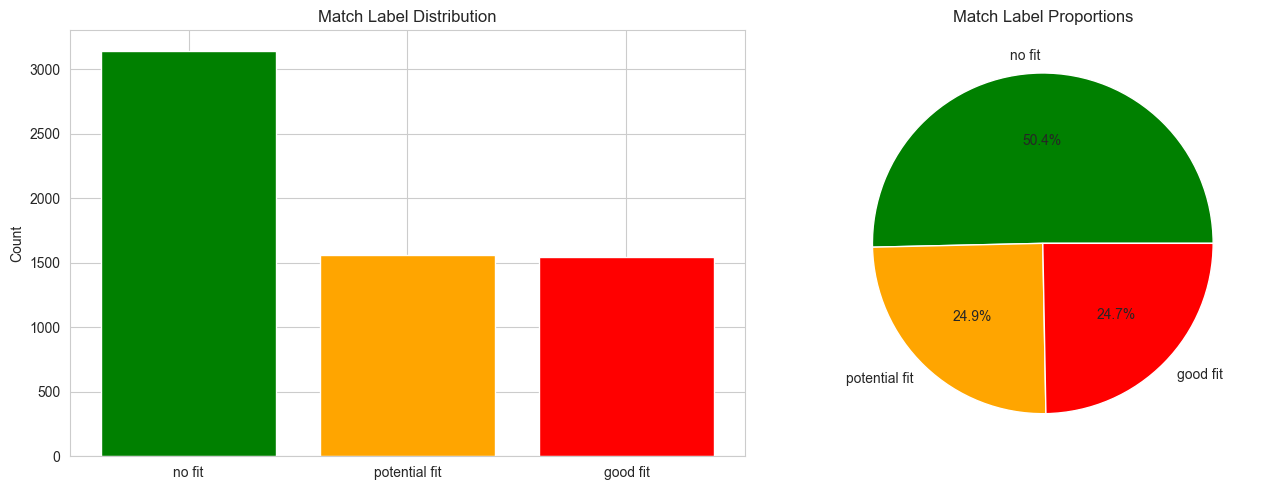

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df["label"].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=["green", "orange", "red"])
axes[0].set_title("Match Label Distribution")   
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", 
            colors=["green", "orange", "red"])

axes[1].set_title("Match Label Proportions")
plt.tight_layout()
plt.show()

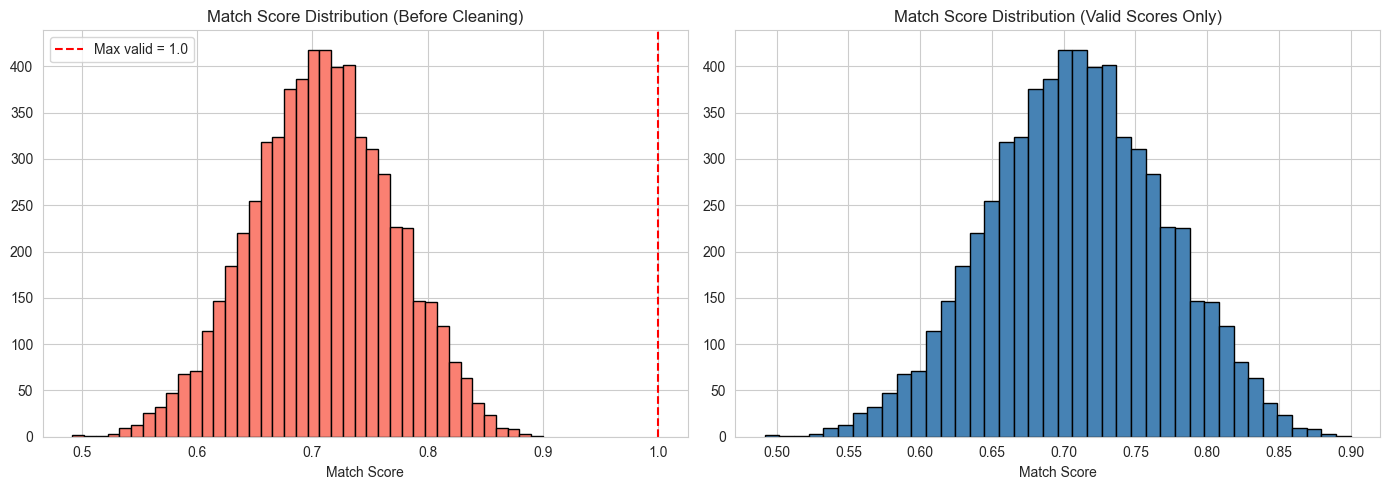

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before Cleaning
axes[0].hist(df["match_score"], bins=40, color="salmon", edgecolor="black")
axes[0].set_title("Match Score Distribution (Before Cleaning)")
axes[0].set_xlabel("Match Score")
axes[0].axvline(1.0, color="red", linestyle="--", label="Max valid = 1.0")
axes[0].legend()

# After Cleaning (only valid scores)
clean = df[(df["match_score"] >= 0) & (df["match_score"] <= 1)]
axes[1].hist(clean["match_score"], bins=40, color="steelblue", edgecolor="black")
axes[1].set_title("Match Score Distribution (Valid Scores Only)")
axes[1].set_xlabel("Match Score")

plt.tight_layout()
plt.show()

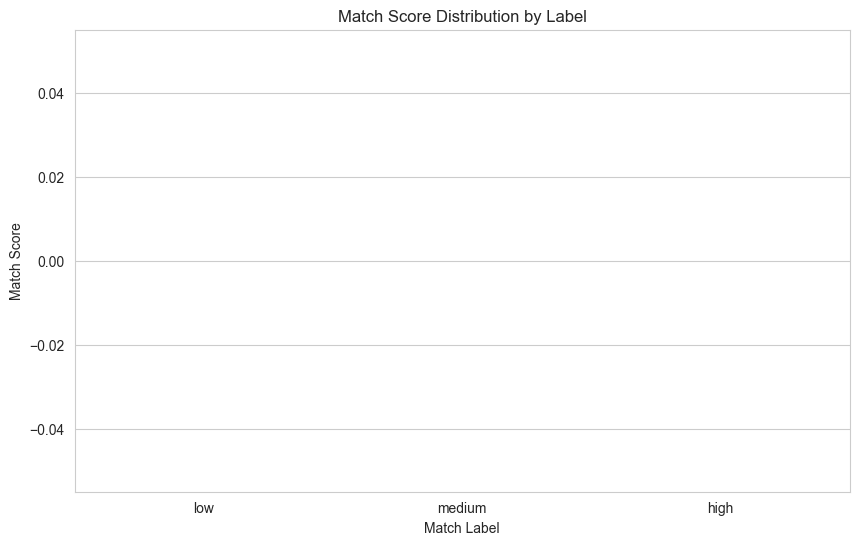

In [15]:
df_plot = df.copy()
df_plot["label_lower"] = df_plot["label"].str.lower()
df_plot = df_plot[(df_plot["match_score"] >= 0) & (df_plot["match_score"] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x="label_lower", y="match_score", 
                order=['low', 'medium', 'high'],
                palette=["red", "orange", "green"])

plt.title("Match Score Distribution by Label")
plt.xlabel("Match Label")
plt.ylabel("Match Score")
plt.show()

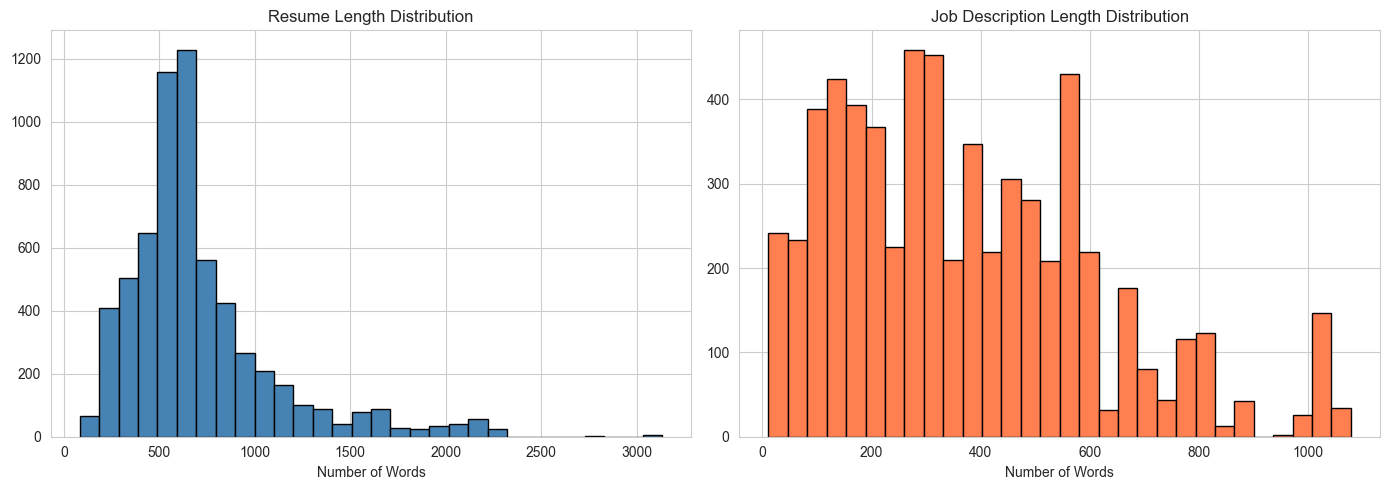

In [16]:
df_plot = df.copy()
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len'] = df_plot['job_description_text'].str.split().str.len()
df_plot["label_lower"] = df_plot["label"].str.lower()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("Resume Length Distribution")
axes[0].set_xlabel("Number of Words")

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title("Job Description Length Distribution")
axes[1].set_xlabel("Number of Words")

plt.tight_layout()
plt.show()

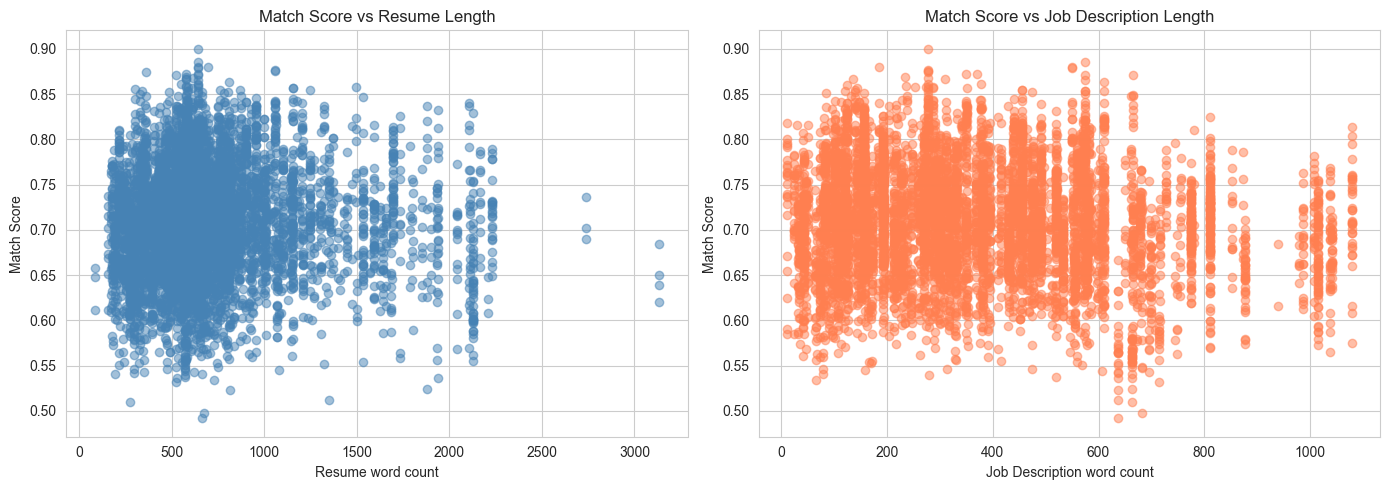

Resume length correlation: 0.011
Job Description length correlation: -0.118


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel("Resume word count")
axes[0].set_ylabel("Match Score")
axes[0].set_title("Match Score vs Resume Length")

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel("Job Description word count")
axes[1].set_ylabel("Match Score")
axes[1].set_title("Match Score vs Job Description Length")
plt.tight_layout()
plt.show()

# Actual Correlation Values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("Job Description length correlation:", df_plot['jd_len'].corr(df_plot['match_score']).round(3))

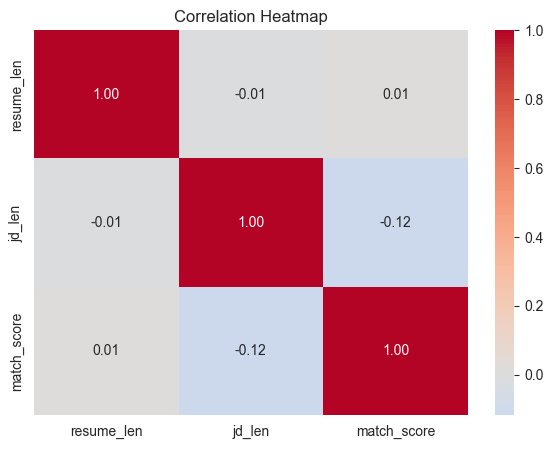

In [18]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [21]:
print("BEFORE CLEANING:")
print("=" * 50)
print(f"Total rows: {len(df)}")
print(f"Null resume text: {df['resume_text'].isnull().sum()}")
print(f"Null job description: {df['job_description_text'].isnull().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Label variants: {df['label'].nunique()}")
print(f"Invalid scores (<0 or >1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

df_clean = df.copy()

BEFORE CLEANING:
Total rows: 6241
Null resume text: 0
Null job description: 0
Duplicates: 1
Label variants: 3
Invalid scores (<0 or >1): 0


In [23]:
print("Before: ", df_clean['label'].value_counts().to_dict())

df_clean['label'] = df_clean['label'].str.lower().str.strip()

print("After: ", df_clean['label'].value_counts().to_dict())
print(f"\nUnique labels now: {df_clean['label'].nunique()} (expected 3)")

Before:  {'No Fit': 3143, 'Potential Fit': 1556, 'Good Fit': 1542}
After:  {'no fit': 3143, 'potential fit': 1556, 'good fit': 1542}

Unique labels now: 3 (expected 3)


In [24]:
print(f"Before dropping nulls: {len(df_clean)} rows")

df_clean = df_clean.dropna(subset=['resume_text', 'job_description_text'])
print(f"After dropping nulls: {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

Before dropping nulls: 6241 rows
After dropping nulls: 6241 rows
Removed: 0 rows


In [26]:
print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text', 'job_description_text']).sum()}")

df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description_text'], keep='first')
print(f"After removing duplicates: {len(df_clean)} rows")

Before removing duplicates: 6241 rows
Duplicate pairs found: 7
After removing duplicates: 6234 rows


In [27]:
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df_clean[invalid_mask][['label', 'match_score']])

df_clean = df_clean[~invalid_mask]
print(f"Rows remaining after removing invalid scores: {len(df_clean)}")

Invalid scores found: 0
Empty DataFrame
Columns: [label, match_score]
Index: []
Rows remaining after removing invalid scores: 6234


In [28]:
print("Score Range per label:")
print(df_clean.groupby('label')['match_score'].agg(['min', 'max', 'mean']).round(2))

def label_score_mismatch(row):
    score = row['match_score']
    label = row['label']

    if label == 'high' and score < 0.70: 
        return True
    if label == 'medium' and (score < 0.35 or score > 0.75):
        return True
    if label == 'low' and score > 0.40:
        return True
    return False

mismatches = df_clean.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")
df_clean[mismatches][['label', 'match_score']]

Score Range per label:
                min   max  mean
label                          
good fit       0.52  0.88  0.73
no fit         0.50  0.90  0.69
potential fit  0.49  0.89  0.72

Label-score mismatches: 0


,label,match_score


In [29]:
df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len'] = df_clean['job_description_text'].str.split().str.len()

print("Short texts found:")
print(f"resume text < 20 words: {(df_clean['resume_len'] < 20).sum()}")
print(f"job description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

df_clean = df_clean[(df_clean['resume_len'] >= 20) & (df_clean['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_clean)}")

Short texts found:
resume text < 20 words: 0
job description < 10 words: 0

Rows after removing short texts: 6234


In [30]:
df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f" Original rows:         {len(df)}")
print(f" Final rows:            {len(df_clean)}")
print(f" Rows removed:          {len(df) - len(df_clean)}")
print()

print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"  Label variants:       {df_clean['label'].nunique()}")
print(f"  Score range:          {df_clean['match_score'].min()} - {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean["label"].value_counts())
print("=" * 45)

CLEANING SUMMARY
 Original rows:         6241
 Final rows:            6234
 Rows removed:          7

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       3
  Score range:          0.4917 - 0.9

Label distribution after cleaning:
label
no fit           3142
potential fit    1554
good fit         1538
Name: count, dtype: int64


In [31]:
df_clean.to_csv('dataset/cleaned_resumeJD_pairs.csv', index=False)
print(f"Saved: dataset/cleaned_resumeJD_pairs.csv ({len(df_clean)} rows)")

Saved: dataset/cleaned_resumeJD_pairs.csv (6234 rows)
